In [6]:
import numpy as np
import pandas as pd

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from catboost import CatBoostClassifier
from Transformer_function import to_delete, to_num_nbin

binary_column = ["gender", "SeniorCitizen", "Partner", "Dependents",
                  "PhoneService", "PaperlessBilling",]
to_binary_column = ["MultipleLines", "OnlineSecurity",
                  "OnlineBackup", "DeviceProtection", "TechSupport",
                  "StreamingTV", "StreamingMovies",]
cat_column = ["remainder__InternetService", "remainder__Contract", "remainder__PaymentMethod",]

model = CatBoostClassifier(cat_features=tuple(cat_column),verbose=0, auto_class_weights="Balanced")

preprocess = ColumnTransformer(transformers=[
    ("to_num_bin", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), binary_column),
    ("to_num_nbin", FunctionTransformer(to_num_nbin), to_binary_column),
],remainder='passthrough')

preprocess.set_output(transform="pandas")
pipeline = Pipeline([
    ("to_delete", FunctionTransformer(to_delete)),
    ("preprocess", preprocess),
    ("model", model)
])

In [8]:
df = pd.read_csv('../../../DATA/Telco-Customer-Churn.csv')

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(["Churn"], axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.12, random_state=42)

In [11]:
import optuna
from tqdm.notebook import tqdm
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        "model__n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "model__max_depth" : trial.suggest_int("max_depth", 2, 10),
        "model__learning_rate" : trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
        "model__subsample": trial.suggest_float("subsample", 0.5, 1.0)
    }

    pipeline.set_params(**params)
    score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy").mean()
    return score

pbar = tqdm(total=25, desc='Optuna tuning')

def tqdm_call_back(study, trial):
    pbar.update(1)
    pbar.set_postfix(best_score=f"{study.best_value:.4f}")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=25, callbacks=[tqdm_call_back])


Optuna tuning:   0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-07-03 12:33:58,050] A new study created in memory with name: no-name-a5017f86-b07b-4cd8-8e9c-0ebe83963cc7
[I 2026-07-03 12:34:09,082] Trial 0 finished with value: 0.7226954837580628 and parameters: {'n_estimators': 191, 'max_depth': 4, 'learning_rate': 0.009652766384925054, 'subsample': 0.5419959579352194}. Best is trial 0 with value: 0.7226954837580628.
[I 2026-07-03 12:34:39,980] Trial 1 finished with value: 0.7525906258692993 and parameters: {'n_estimators': 378, 'max_depth': 6, 'learning_rate': 0.02255780768638794, 'subsample': 0.9503788229552865}. Best is trial 1 with value: 0.7525906258692993.
[I 2026-07-03 12:34:55,165] Trial 2 finished with value: 0.6864984204058231 and parameters: {'n_estimators': 442, 'max_depth': 2, 'learning_rate': 0.0019691935876931534, 'subsample': 0.8061730484616212}. Best is trial 1 with value: 0.7525906258692993.
[I 2026-07-03 12:35:18,162] Trial 3 finished with value: 0.7181697080983096 and parameters: {'n_estimators': 399, 'max_depth': 4, 'le

In [12]:
study.best_params
params={
        "model__n_estimators": study.best_params["n_estimators"],
        "model__max_depth" :study.best_params["max_depth"],
        "model__learning_rate" : study.best_params["learning_rate"],
        "model__subsample": study.best_params["subsample"],
    }

In [13]:
model = pipeline.set_params(**params)

In [14]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('to_delete', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['customerID','gender','SeniorCitizen',...,'PaymentMethod', 'MonthlyCharges','TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function to_...0022966F5F880>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

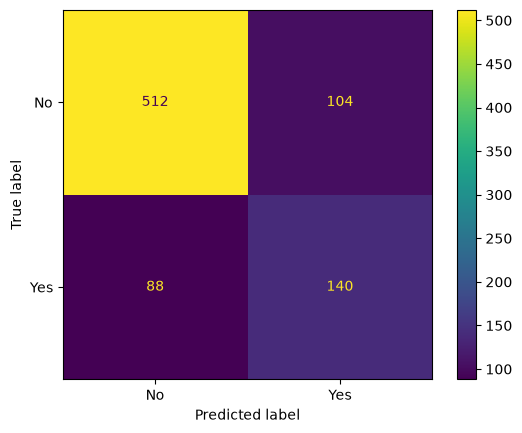

In [16]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

In [17]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.85      0.83      0.84       616
         Yes       0.57      0.61      0.59       228

    accuracy                           0.77       844
   macro avg       0.71      0.72      0.72       844
weighted avg       0.78      0.77      0.77       844



In [18]:
import joblib

joblib.dump(model, "Data/model.joblib")

['Data/model.joblib']